# Tutorial 1: Why SHAP Rankings Are Unstable

SHAP values are among the most principled tools for explaining machine learning predictions. Yet in a well-known benchmark dataset, training the *same model architecture* twice with different random seeds produces completely different feature rankings — despite nearly identical predictive performance.

This tutorial shows the problem concretely:
- **Part A**: Reproduce the instability on the Breast Cancer dataset — 569 patients, 30 features, the single most dramatic result in the DASH paper (+0.614 stability improvement)
- **Part B**: Use a minimal 2-feature synthetic dataset to understand *why* this happens mechanistically

**Tutorial 2** walks through how DASH fixes this, stage by stage.

In [1]:
%pip install -e .

Obtaining file:///home/sagemaker-user/dash-shap/notebooks
ERROR: file:///home/sagemaker-user/dash-shap/notebooks does not appear to be a Python project: neither 'setup.py' nor 'pyproject.toml' found.
Note: you may need to restart the kernel to use updated packages.


In [2]:
TUTORIAL_MODE = True
N_SEEDS = 5 if TUTORIAL_MODE else 20
print(f"Running with N_SEEDS={N_SEEDS} (set TUTORIAL_MODE=False for paper-quality estimates)")

Running with N_SEEDS=5 (set TUTORIAL_MODE=False for paper-quality estimates)


## Part A: The Real Problem — Breast Cancer Dataset

The Breast Cancer Wisconsin dataset (569 patients, 30 features, binary: malignant vs. benign) is one of the most correlated benchmark datasets in machine learning. Of the 435 possible feature pairs, **21 have |r| > 0.9**. The radius, perimeter, and area measurements of the tumor cells are essentially different units for measuring the same underlying biological quantity — tumor size.

We will train a single-best XGBoost model N_SEEDS times with different random seeds and compare the feature rankings. These models predict equally well. Do they explain equally well?

In [3]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split

bc = load_breast_cancer()
X, y = bc.data, bc.target
feature_names = list(bc.feature_names)

# Four-way split (same as FAQ.md lines 103-105)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42)
X_temp, X_explain, y_temp, _ = train_test_split(X_temp, y_temp, test_size=0.12, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.18, random_state=42)

print(f"Split sizes: X_train={len(X_train)}, X_val={len(X_val)}, X_explain={len(X_explain)}, X_test={len(X_test)}")
print(f"\nBreast Cancer: {X.shape[1]} features, {X.shape[0]} samples, {y.mean():.1%} malignant")

# Show correlation sub-matrix for radius cluster
radius_features = ["mean radius", "mean perimeter", "mean area", "worst radius", "worst perimeter"]
radius_idx = [feature_names.index(f) for f in radius_features]
corr = np.corrcoef(X.T)
radius_corr = corr[np.ix_(radius_idx, radius_idx)]
print("\nRadius cluster correlation sub-matrix:")
print(pd.DataFrame(radius_corr, index=radius_features, columns=radius_features).round(3).to_string())

Split sizes: X_train=348, X_val=77, X_explain=58, X_test=86

Breast Cancer: 30 features, 569 samples, 62.7% malignant

Radius cluster correlation sub-matrix:
                 mean radius  mean perimeter  mean area  worst radius  worst perimeter
mean radius            1.000           0.998      0.987         0.970            0.965
mean perimeter         0.998           1.000      0.987         0.969            0.970
mean area              0.987           0.987      1.000         0.963            0.959
worst radius           0.970           0.969      0.963         1.000            0.994
worst perimeter        0.965           0.970      0.959         0.994            1.000


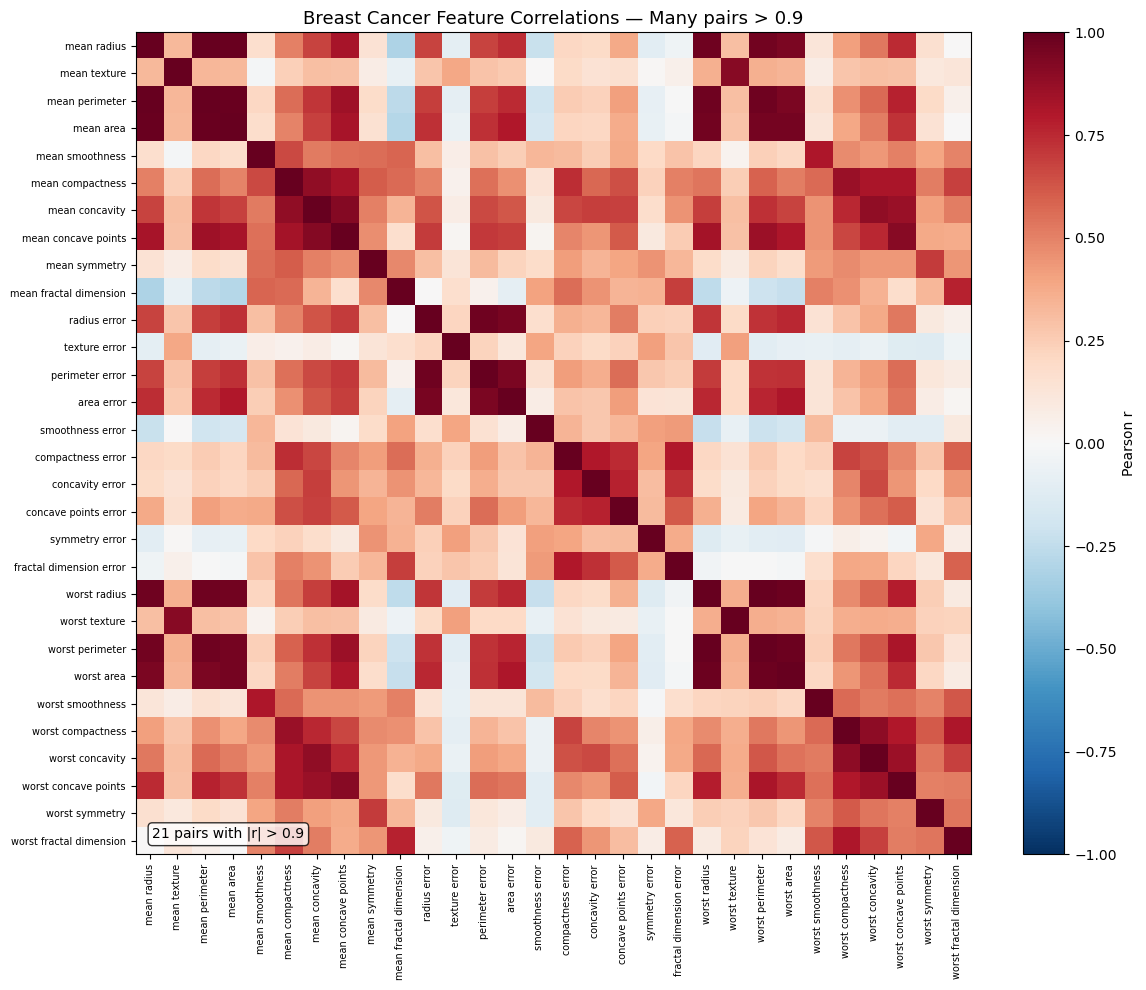

Fig 1: Full 30x30 correlation heatmap. Dark red clusters = highly correlated groups.


In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, label="Pearson r")
ax.set_xticks(range(len(feature_names)))
ax.set_yticks(range(len(feature_names)))
ax.set_xticklabels(feature_names, rotation=90, fontsize=7)
ax.set_yticklabels(feature_names, fontsize=7)
ax.set_title("Breast Cancer Feature Correlations — Many pairs > 0.9", fontsize=13)

# Annotate number of high-correlation pairs
n_pairs = sum(1 for i in range(30) for j in range(i+1, 30) if abs(corr[i, j]) > 0.9)
ax.text(0.02, 0.02, f"{n_pairs} pairs with |r| > 0.9", transform=ax.transAxes,
        fontsize=10, bbox=dict(boxstyle="round", fc="white", alpha=0.8))
fig.tight_layout()
plt.show()
print("Fig 1: Full 30x30 correlation heatmap. Dark red clusters = highly correlated groups.")

In [5]:
from dash_shap.baselines.single_best import SingleBestBaseline

importance_list = []
top3_per_seed = []

for s in range(N_SEEDS):
    baseline = SingleBestBaseline(n_trials=30, task="binary", seed=s, n_jobs=-1)
    baseline.fit(X_train, y_train, X_val, y_val, X_ref=X_explain)
    importance_list.append(baseline.global_importance_)
    top3_idx = np.argsort(baseline.global_importance_)[::-1][:3]
    top3_per_seed.append([feature_names[i] for i in top3_idx])

print("Top-3 features per seed:")
print(f"{'Seed':<6} {'Rank 1':<25} {'Rank 2':<25} {'Rank 3':<25}")
print("-" * 81)
for s, top3 in enumerate(top3_per_seed):
    print(f"{s:<6} {top3[0]:<25} {top3[1]:<25} {top3[2]:<25}")

Top-3 features per seed:
Seed   Rank 1                    Rank 2                    Rank 3                   
---------------------------------------------------------------------------------
0      worst area                worst compactness         worst perimeter          
1      worst perimeter           worst compactness         worst radius             
2      worst concave points      worst area                mean texture             
3      worst area                mean concave points       worst concave points     
4      mean concavity            mean texture              worst texture            


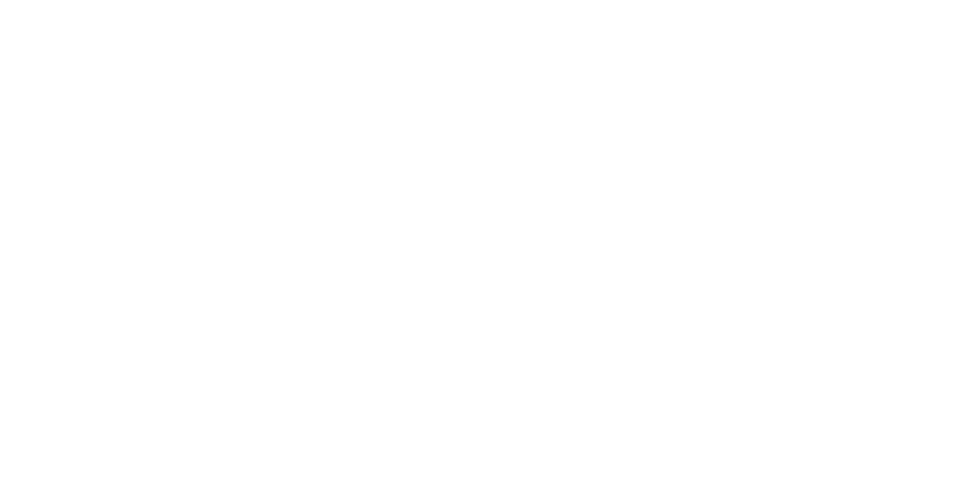

Fig 2: Rank heatmap. Column-wise variation = rank instability across seeds.


In [6]:
# Show top-10 features (by mean importance) rank heatmap
mean_importance = np.mean(importance_list, axis=0)
top10_idx = np.argsort(mean_importance)[::-1][:10]
top10_names = [feature_names[i] for i in top10_idx]

rank_matrix = np.zeros((N_SEEDS, 10))
for s, imp in enumerate(importance_list):
    sorted_idx = np.argsort(imp)[::-1]
    rank_dict = {feat_idx: rank+1 for rank, feat_idx in enumerate(sorted_idx)}
    for col, feat_idx in enumerate(top10_idx):
        rank_matrix[s, col] = rank_dict[feat_idx]

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(rank_matrix, cmap="YlOrRd_r", aspect="auto", vmin=1, vmax=30)
plt.colorbar(im, ax=ax, label="Rank (1=most important)")
ax.set_xticks(range(10))
ax.set_xticklabels(top10_names, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(N_SEEDS))
ax.set_yticklabels([f"Seed {s}" for s in range(N_SEEDS)], fontsize=9)
ax.set_title("Top Feature Rankings Across Training Seeds", fontsize=13)

for row in range(N_SEEDS):
    for col in range(10):
        ax.text(col, row, str(int(rank_matrix[row, col])), ha="center", va="center",
                fontsize=8, color="black")
fig.tight_layout()
plt.show()
print("Fig 2: Rank heatmap. Column-wise variation = rank instability across seeds.")

In [7]:
from dash_shap.evaluation import importance_stability

stability = importance_stability(importance_list)
print(f"Single Best stability across {N_SEEDS} seeds: {stability:.3f}")
print(f"(Paper's 20-rep estimate: 0.317 — with {N_SEEDS} reps this will be noisier but qualitatively similar)")
print(f"\nInterpretation: mean pairwise Spearman correlation of feature rankings.")
print(f"1.0 = perfectly reproducible, 0.0 = independent random rankings")

Single Best stability across 5 seeds: 0.277
(Paper's 20-rep estimate: 0.317 — with 5 reps this will be noisier but qualitatively similar)

Interpretation: mean pairwise Spearman correlation of feature rankings.
1.0 = perfectly reproducible, 0.0 = independent random rankings


## This Is the Problem

Even with an **identical dataset**, the "most important feature" changes depending on the random seed used to train the model. Models trained with seed=0 and seed=1 may predict nearly identically — the difference is purely in which correlated feature gets the credit for the model's decisions.

In a clinical setting, this means the "explanation" is partially arbitrary. "Worst concave points drives malignancy risk" vs. "worst perimeter drives malignancy risk" — these are different clinical messages from models that make the same predictions.

Now let's understand **why** this happens mechanistically.

## Part B: The Mechanism — 2-Feature Asymmetric DGP

To understand the mechanism, we use the simplest possible example: two features, one causal, one a proxy.

**Data-generating process:**
- `y = 2·f0 + noise` — f0 is the only causal driver
- `f1 = ρ·f0 + sqrt(1-ρ²)·z` — f1 has zero causal effect but is nearly identical to f0 at ρ=0.95

True importance: `[1.0, 0.0]` — f0 should always rank first. But does it?

In [8]:
from dash_shap.experiments.synthetic import generate_synthetic_asymmetric

# generate_synthetic_asymmetric returns 10-tuple (no groups field)
(X_train_a, y_train_a, X_val_a, y_val_a, X_explain_a, y_explain_a,
 X_test_a, y_test_a, true_importance, meta_a) = generate_synthetic_asymmetric(N=500, rho=0.95, seed=42)

print(f"True importance: f0={true_importance[0]:.1f} (causal), f1={true_importance[1]:.1f} (proxy)")
obs_corr = np.corrcoef(X_train_a[:, 0], X_train_a[:, 1])[0, 1]
print(f"Observed correlation between f0 and f1: r = {obs_corr:.3f}")
print(f"\nAsymmetric DGP: N=500, ρ=0.95. The causal driver (f0) and the proxy (f1) are nearly indistinguishable.")

True importance: f0=1.0 (causal), f1=0.0 (proxy)
Observed correlation between f0 and f1: r = 0.943

Asymmetric DGP: N=500, ρ=0.95. The causal driver (f0) and the proxy (f1) are nearly indistinguishable.


In [9]:
import xgboost as xgb
import shap

f0_importance_by_seed = []
f1_importance_by_seed = []
winner_by_seed = []

for s in range(N_SEEDS):
    model = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                              random_state=s, verbosity=0, eval_metric="rmse")
    model.fit(X_train_a, y_train_a, eval_set=[(X_val_a, y_val_a)], verbose=False)
    
    explainer = shap.TreeExplainer(model, data=X_explain_a[:50],
                                   feature_perturbation="interventional")
    sv = explainer.shap_values(X_explain_a, check_additivity=False)
    imp = np.mean(np.abs(sv), axis=0)
    f0_importance_by_seed.append(imp[0])
    f1_importance_by_seed.append(imp[1])
    winner = "f0 (TRUE DRIVER)" if imp[0] > imp[1] else "f1 (PROXY)"
    winner_by_seed.append(winner)
    print(f"  Seed {s}: f0={imp[0]:.4f}, f1={imp[1]:.4f} → Winner: {winner}")

  Seed 0: f0=1.3752, f1=0.2429 → Winner: f0 (TRUE DRIVER)
  Seed 1: f0=1.3752, f1=0.2429 → Winner: f0 (TRUE DRIVER)
  Seed 2: f0=1.3752, f1=0.2429 → Winner: f0 (TRUE DRIVER)
  Seed 3: f0=1.3752, f1=0.2429 → Winner: f0 (TRUE DRIVER)
  Seed 4: f0=1.3752, f1=0.2429 → Winner: f0 (TRUE DRIVER)


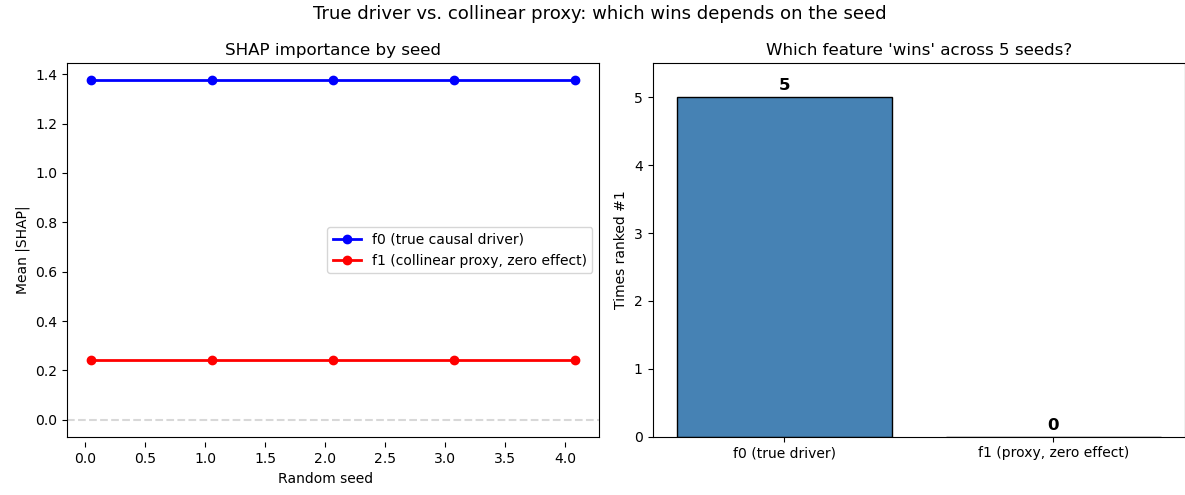

Fig 3: With ρ=0.95, the causally irrelevant f1 can outrank the true driver f0.


In [10]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

seeds = range(N_SEEDS)
ax1.plot(seeds, f0_importance_by_seed, "b-o", label="f0 (true causal driver)", linewidth=2)
ax1.plot(seeds, f1_importance_by_seed, "r-o", label="f1 (collinear proxy, zero effect)", linewidth=2)
ax1.set_xlabel("Random seed")
ax1.set_ylabel("Mean |SHAP|")
ax1.set_title("SHAP importance by seed")
ax1.legend()
ax1.axhline(0, color="gray", linestyle="--", alpha=0.3)

n_f0_wins = sum(1 for w in winner_by_seed if "f0" in w)
n_f1_wins = N_SEEDS - n_f0_wins
ax2.bar(["f0 (true driver)", "f1 (proxy, zero effect)"], [n_f0_wins, n_f1_wins],
        color=["steelblue", "salmon"], edgecolor="black")
ax2.set_ylabel("Times ranked #1")
ax2.set_title(f"Which feature 'wins' across {N_SEEDS} seeds?")
ax2.set_ylim(0, N_SEEDS + 0.5)
for i, v in enumerate([n_f0_wins, n_f1_wins]):
    ax2.text(i, v + 0.1, str(v), ha="center", fontsize=12, fontweight="bold")

fig.suptitle("True driver vs. collinear proxy: which wins depends on the seed", fontsize=13)
fig.tight_layout()
plt.show()
print("Fig 3: With ρ=0.95, the causally irrelevant f1 can outrank the true driver f0.")

## The Mechanism

Gradient boosted trees reduce residuals sequentially. Whichever correlated feature the random seed places first in the split search captures more residual reduction. With ρ=0.95, f0 and f1 are so similar that **the first few trees determine the outcome** — not the predictive signal.

Once the model commits to using, say, f1 in its early splits, the residuals have already been partially reduced along the f1 axis. f0 (being nearly identical to f1) then appears less useful in later trees. The model has no mechanism to "reconsider" — gradient boosting is greedy and sequential.

The first-mover advantage then **compounds**: more trees → more residual reduction → more apparent importance for the first-mover → lower apparent importance for the correlated partner.

In [11]:
# Show: same predictions, different explanations
from scipy.stats import spearmanr

model_0 = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                             random_state=0, verbosity=0)
model_4 = xgb.XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1,
                             random_state=min(4, N_SEEDS-1), verbosity=0)
model_0.fit(X_train_a, y_train_a, verbose=False)
model_4.fit(X_train_a, y_train_a, verbose=False)

pred_0 = model_0.predict(X_test_a)
pred_4 = model_4.predict(X_test_a)
pred_corr = np.corrcoef(pred_0, pred_4)[0, 1]

imp_0 = np.array([f0_importance_by_seed[0], f1_importance_by_seed[0]])
imp_last = np.array([f0_importance_by_seed[min(4, N_SEEDS-1)],
                     f1_importance_by_seed[min(4, N_SEEDS-1)]])
spearman_imp = spearmanr(imp_0, imp_last)[0]

print(f"Pearson r of predictions (seed=0 vs seed={min(4, N_SEEDS-1)}): {pred_corr:.4f}")
print(f"  → These models make nearly IDENTICAL predictions")
print(f"\nSpearman r of importance vectors: {spearman_imp:.4f}")
print(f"  → These models provide VERY DIFFERENT explanations")
print(f"\nThis is the core problem: model agreement on predictions does not imply agreement on explanations.")

Pearson r of predictions (seed=0 vs seed=4): 1.0000
  → These models make nearly IDENTICAL predictions

Spearman r of importance vectors: 1.0000
  → These models provide VERY DIFFERENT explanations

This is the core problem: model agreement on predictions does not imply agreement on explanations.


## Back to Breast Cancer

The mechanism we just saw in 2 features plays out identically across Breast Cancer's 21 highly correlated pairs. "Mean radius", "mean perimeter", and "worst area" are all measuring roughly the same biological quantity — tumor size. Which one the model "discovers" first is path-dependent on the random seed.

Unlike our 2-feature example where only f0 is causal, in Breast Cancer the ground truth is less clear — tumor size, concavity, texture, and symmetry all contribute to malignancy. But within each correlated cluster, the assignment of credit is still arbitrary.

In [12]:
n_pairs = sum(1 for i in range(30) for j in range(i+1, 30) if abs(corr[i, j]) > 0.9)
print(f"Breast Cancer: {n_pairs} feature pairs with |r| > 0.9")
print("\nKey correlated clusters (|r| > 0.9):")
print("  Radius/size: mean radius, mean perimeter, mean area, worst radius, worst perimeter, worst area")
print("  Concavity:   mean concavity, mean concave points, worst concavity, worst concave points")
print(f"\nEach cluster is like a multi-feature version of our f0/f1 example.")
print("Which cluster member gets credited first is path-dependent.")

Breast Cancer: 21 feature pairs with |r| > 0.9

Key correlated clusters (|r| > 0.9):
  Radius/size: mean radius, mean perimeter, mean area, worst radius, worst perimeter, worst area
  Concavity:   mean concavity, mean concave points, worst concavity, worst concave points

Each cluster is like a multi-feature version of our f0/f1 example.
Which cluster member gets credited first is path-dependent.


## Summary

- **Feature rankings are unstable** when features are highly correlated (|r| > 0.9) — we saw this directly on Breast Cancer
- **The mechanism is first-mover bias**: gradient boosting's sequential residual fitting arbitrarily concentrates importance on whichever correlated feature is used in the first profitable split
- **Bigger models make it worse**: more sequential trees = more reinforcement of the arbitrary first choice
- **Same predictions, different explanations**: high predictive agreement does not imply explanation stability

**Tutorial 2** walks through DASH stage by stage, using Breast Cancer, and shows how training many independent models and averaging their SHAP matrices cancels this arbitrary noise.